
# Hybrid Query Selection Workflow for Bayesian Optimization

This notebook demonstrates a **hybrid strategy** for selecting query points in a Bayesian Optimization setting.  
The approach combines:
- **Acquisition functions** (Expected Improvement and Upper Confidence Bound) for systematic exploration/exploitation.
- **Targeted perturbations** around top-performing points for flexibility and faster convergence.

### Why Hybrid?
- Pure exploration can miss subtle nonlinear interactions.
- Pure exploitation risks premature convergence.
- A hybrid approach accelerates learning while maintaining diversity.

---

### Directions for Use:
1. **Run the setup cells** to load functions for GP fitting, acquisition functions, perturbations, and visualisations.
2. **Provide your observed data** (`X`, `Y`) from previous rounds.
3. **Fit the GP model** and compute acquisition scores.
4. **Generate candidate queries** using the hybrid strategy.
5. **Visualise results** to guide your next round of submissions.


In [46]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import pandas as pd



## Step 1: Fit a Gaussian Process Surrogate Model
We use a GP with an RBF kernel to model the unknown function based on observed data.


In [47]:

def fit_gp(X, Y, length_scale=0.5, noise=1e-6):
    kernel = RBF(length_scale=length_scale, length_scale_bounds='fixed')
    gp = GaussianProcessRegressor(kernel=kernel, alpha=noise, normalize_y=True)
    gp.fit(X, Y)
    return gp

def predict_gp(gp, X_grid):
    mean, std = gp.predict(X_grid, return_std=True)
    return mean, std


## Step 2: Acquisition Functions
We implement:
- **Expected Improvement (EI)** for exploitation.
- **Upper Confidence Bound (UCB)** for exploration.


In [48]:

def expected_improvement(X_grid, gp, Y_best, xi=0.01):
    mean, std = gp.predict(X_grid, return_std=True)
    std = std.reshape(-1, 1)
    mean = mean.reshape(-1, 1)
    Z = (mean - Y_best - xi) / std
    ei = (mean - Y_best - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    return ei.flatten()

def upper_confidence_bound(X_grid, gp, kappa=2.5):
    mean, std = gp.predict(X_grid, return_std=True)
    ucb = mean + kappa * std
    return ucb


## Step 3: Targeted Perturbations
Generate small random variations around top-performing points to refine promising regions.


In [49]:

def generate_perturbations(top_points, perturbation_rate=0.05, bounds=(0, 1)):
    perturbed_points = []
    for point in top_points:
        perturbation = point + np.random.uniform(-perturbation_rate, perturbation_rate, size=point.shape)
        perturbation = np.clip(perturbation, bounds[0], bounds[1])
        perturbed_points.append(perturbation)
    return np.array(perturbed_points)


## Step 4: Hybrid Query Selection
Combine acquisition-driven candidates with perturbations for a balanced strategy.


In [50]:

def hybrid_query_selection(X_grid, gp, Y_best, top_points, n_queries=10):
    ei_scores = expected_improvement(X_grid, gp, Y_best)
    ucb_scores = upper_confidence_bound(X_grid, gp)
    ei_top_idx = np.argsort(ei_scores)[-n_queries//2:]
    ucb_top_idx = np.argsort(ucb_scores)[-n_queries//2:]
    acquisition_candidates = X_grid[np.unique(np.concatenate([ei_top_idx, ucb_top_idx]))]
    perturbation_candidates = generate_perturbations(top_points, perturbation_rate=0.05)
    combined_candidates = np.vstack([acquisition_candidates, perturbation_candidates])
    return combined_candidates


## Step 5: Visualisation
Visualise GP predictions, acquisition functions, and query points.


In [51]:

def plot_gp_1d(X, Y, X_grid, gp, beta=1.96):
    mean, std = gp.predict(X_grid, return_std=True)
    
    plt.figure(figsize=(10, 6))
    # Observed points
    ## Handle multi-dimensional X
    # plt.scatter(X, Y, color='red', label='Observed Points')
    
    if X.shape[1] == 1:
        plt.scatter(X.flatten(), Y, color='red', label='Observed Points')
    else:
        plt.scatter(X[:, 0], Y, color='red', label='Observed Points (Dim 1)')

    
    # GP Posterior Mean
    plt.plot(X_grid[:, 0], mean, color='blue', label='GP Posterior Mean')
    
    # Confidence Interval
    # plt.fill_between(X_grid[:, 0].flatten(),
    plt.fill_between(X_grid[:, 0],
                     mean - beta * std,
                     mean + beta * std,
                     alpha=0.2, color='blue', label='95% Confidence Interval')
    
    # Annotations
    #plt.annotate('Posterior Mean (Best Guess)', xy=(0.7, mean[70]), xytext=(0.5, mean[70]+0.5),
    #             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')
   # plt.annotate('Confidence Interval (Uncertainty)', xy=(0.3, mean[30]+beta*std[30]), xytext=(0.1, mean[30]+1),
   #              arrowprops=dict(facecolor='gray', shrink=0.05), fontsize=10, color='gray')


    ##plt.annotate('Posterior Mean (Best Guess)',
                 #xy=(X_grid[int(len(X_grid)*0.7), 0], mean[int(len(mean)*0.7)]),
                 #xytext=(X_grid[int(len(X_grid)*0.5), 0], mean[int(len(mean)*0.7)] + 0.5),
    #             xy=(X_grid[int(n_points*0.7)], mean[int(n_points*0.7)]),
    #             xytext=(X_grid[int(n_points*0.7)] + 0.05, mean[int(n_points*0.7)] + 0.05),
    #             arrowprops=dict(facecolor='blue', shrink=0.05),
    #             fontsize=10, color='blue')

    #plt.annotate('Confidence Interval (Uncertainty)',
                 #xy=(X_grid[int(len(X_grid)*0.3), 0], mean[int(len(mean)*0.3)] + beta * std[int(len(std)*0.3)]),
                 #xytext=(X_grid[int(len(X_grid)*0.1), 0], mean[int(len(mean)*0.3)] + 1),
    #             xy=(X_grid[int(n_points*0.3)], mean[int(n_points*0.3)] + beta * std[int(n_points*0.3)]),
    #             xytext=(X_grid[int(n_points*0.3)] + 0.05, mean[int(n_points*0.3)] + 0.05),
    #             arrowprops=dict(facecolor='gray', shrink=0.05),
    #             fontsize=10, color='gray')

    
    # Cleaner labels without arrows
    plt.text(X_grid[int(n_points*0.7)], mean[int(n_points*0.7)], 'Posterior Mean', color='blue', fontsize=9)
    plt.text(X_grid[int(n_points*0.3)], mean[int(n_points*0.3)] + beta * std[int(n_points*0.3)], 'Uncertainty', color='gray', fontsize=9)

    
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.title('Surrogate Model: Posterior Mean and Uncertainty')
    plt.legend()
    plt.show()

    
def plot_acquisition_functions(X_grid, ei_scores, ucb_scores):
    plt.figure(figsize=(10, 6))
    plt.plot(X_grid, ei_scores, label='Expected Improvement', color='green')
    plt.plot(X_grid, ucb_scores, label='Upper Confidence Bound', color='orange')
    plt.xlabel('Input')
    plt.ylabel('Acquisition Score')
    plt.title('Acquisition Functions')
    plt.legend()
    plt.show()

def plot_parallel_coordinates(X, Y):
    df = pd.DataFrame(X, columns=[f'Dim{i+1}' for i in range(X.shape[1])])
    df['Output'] = Y
    plt.figure(figsize=(12, 6))
    parallel_coordinates(df, 'Output', colormap='viridis')
    plt.title('Parallel Coordinates for High-Dimensional Queries')
    plt.show()


# NEW FUNCTION: Handles 1D and 2D slices for high-dimensional input
def plot_gp_slice(X, Y, gp, dims_to_vary=[0], query_point=None, beta=1.96, n_points=50):
    """
    Visualize GP predictions for high-dimensional input by varying selected dimensions
    and fixing others at their median values.
    dims_to_vary: list of dimension indices to vary (1D or 2D slice)
    """
    fixed_values = np.median(X, axis=0)

    if len(dims_to_vary) == 1:
        # 1D slice
        var_dim = dims_to_vary[0]
        X_grid = np.linspace(0, 1, n_points)
        X_full = np.tile(fixed_values, (n_points, 1))
        X_full[:, var_dim] = X_grid
        mean, std = gp.predict(X_full, return_std=True)

        plt.figure(figsize=(10, 6))
        plt.scatter(X[:, var_dim], Y, color='red', label='Observed Points')
        plt.plot(X_grid, mean, color='blue', label='GP Posterior Mean')
        plt.fill_between(X_grid, mean - beta * std, mean + beta * std,
                         alpha=0.2, color='blue', label='95% Confidence Interval')
        
        # Highlight query point
        if query_point is not None:
            plt.scatter(query_point[var_dim], gp.predict(query_point.reshape(1, -1))[0],
                        color='black', s=100, marker='*', label='Chosen Query')


        # Annotations
        #plt.annotate('Posterior Mean (Best Guess)',
        #             xy=(X_grid[int(n_points*0.7)], mean[int(n_points*0.7)]),
        #             xytext=(X_grid[int(n_points*0.5)], mean[int(n_points*0.7)] + 0.5),
        #             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')
        #plt.annotate('Confidence Interval (Uncertainty)',
        #             xy=(X_grid[int(n_points*0.3)], mean[int(n_points*0.3)] + beta * std[int(n_points*0.3)]),
        #             xytext=(X_grid[int(n_points*0.1)], mean[int(n_points*0.3)] + 1),
        #             arrowprops=dict(facecolor='gray', shrink=0.05), fontsize=10, color='gray')


        # Cleaner markers + labels (no arrows)
        plt.scatter(X_grid[int(n_points*0.7)], mean[int(n_points*0.7)],
                    color='blue', s=80, marker='o', label='Posterior Mean')
        plt.text(X_grid[int(n_points*0.7)] + 0.02, mean[int(n_points*0.7)],
                 'Posterior Mean', color='blue', fontsize=9)
        
        plt.scatter(X_grid[int(n_points*0.3)], mean[int(n_points*0.3)] + beta * std[int(n_points*0.3)],
                    color='gray', s=80, marker='o', label='Uncertainty')
        plt.text(X_grid[int(n_points*0.3)] + 0.02,
                 mean[int(n_points*0.3)] + beta * std[int(n_points*0.3)],
                 'Uncertainty', color='gray', fontsize=9)


        plt.xlabel(f'Dimension {var_dim+1}')
        plt.ylabel('Output')
        plt.title(f'1D Slice (Other dims fixed at median)')
        plt.legend()
        plt.show()

    elif len(dims_to_vary) == 2:
        # 2D slice
        d1, d2 = dims_to_vary
        grid1 = np.linspace(0, 1, n_points)
        grid2 = np.linspace(0, 1, n_points)
        X_full = np.tile(fixed_values, (n_points * n_points, 1))
        X_full[:, d1] = np.repeat(grid1, n_points)
        X_full[:, d2] = np.tile(grid2, n_points)
        mean, _ = gp.predict(X_full, return_std=True)

        Z = mean.reshape(n_points, n_points)
        plt.figure(figsize=(8, 6))
        plt.contourf(grid1, grid2, Z, cmap='viridis')
        plt.colorbar(label='GP Posterior Mean')
        plt.scatter(X[:, d1], X[:, d2], color='red', label='Observed Points')

        # Highlight query point
        if query_point is not None:
            plt.scatter(query_point[d1], query_point[d2], color='black', s=100, marker='*', label='Chosen Query')

        plt.xlabel(f'Dimension {d1+1}')
        plt.ylabel(f'Dimension {d2+1}')
        plt.title(f'2D Slice (Other dims fixed at median)')
        plt.legend()
        plt.show()



## Example Usage
Below is an example for a 1D function. Replace `X` and `Y` with your observed data.


In [54]:
X = np.load('function_1/initial_inputs.npy')  # Actually an npy file
Y = np.load('function_1/initial_outputs.npy')  # Actually an npy file
print(X)
print(Y)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]


Shape of X: (10, 2)
Shape of Y: (10,)


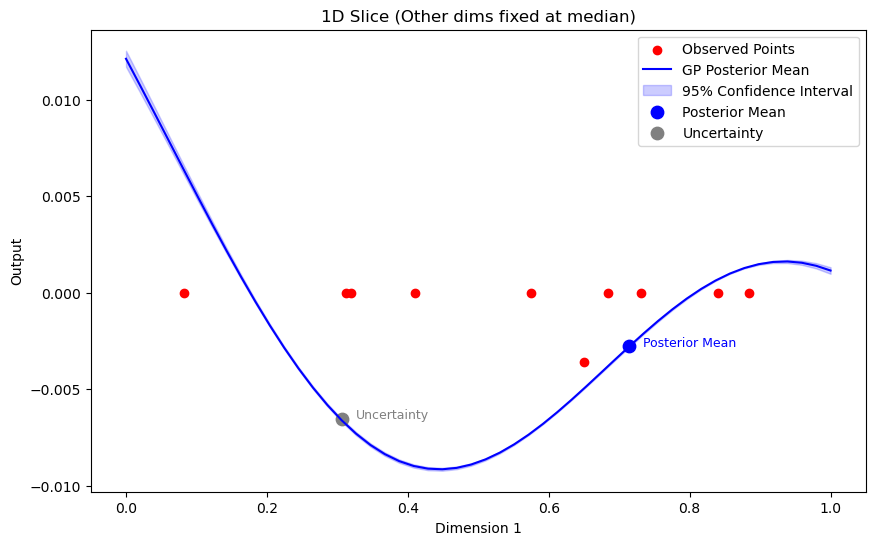

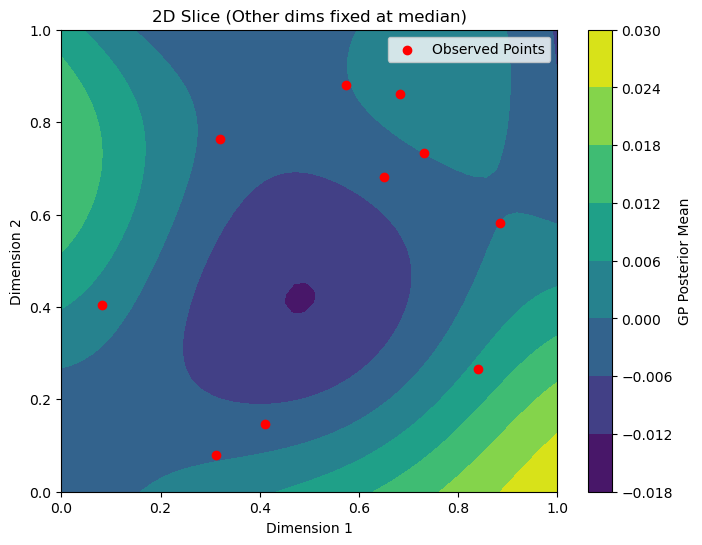

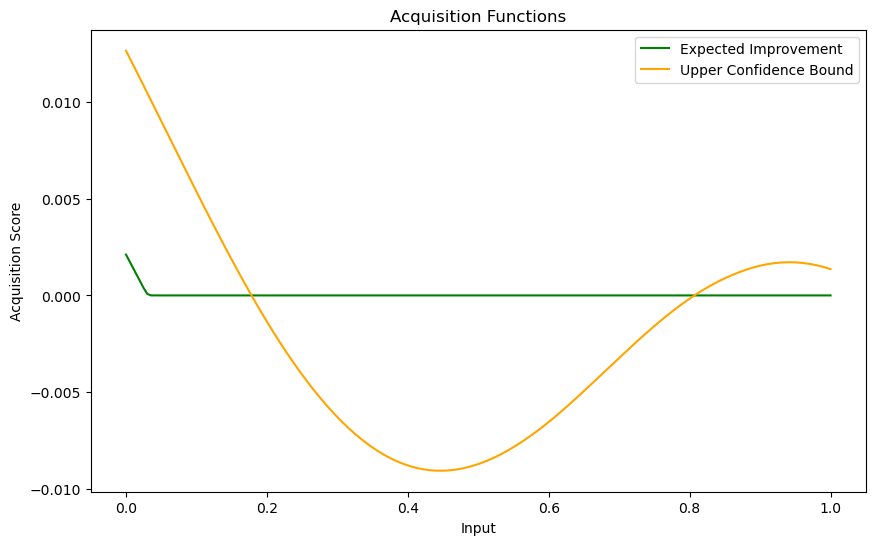

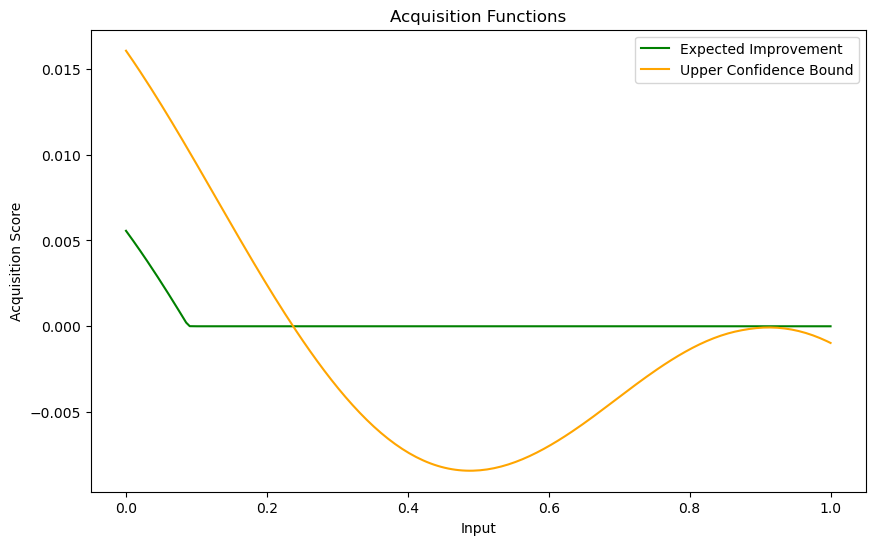

In [52]:


import numpy as np

# Load data from npy files (replace with actual file paths)
X = np.load('function_1/initial_inputs.npy')  # Actually an npy file
Y = np.load('function_1/initial_outputs.npy')  # Actually an npy file

# Reshape X if needed (e.g., for 1D function)
if X.ndim == 1:
    X = X.reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

# Fit GP and compute acquisition scores
gp = fit_gp(X, Y)

# Generate prediction grid based on dimensionality
#X_grid = np.linspace(0, 1, 100).reshape(-1, 1)
X_grid = np.random.uniform(0, 1, size =(1000,X.shape[1]))
#X_grid = np.linspace(0, 1, 200).reshape(-1, X.shape[1]) if X.shape[1] == 1 else np.random.uniform(0, 1, size=(500, X.shape[1]))

ei_scores = expected_improvement(X_grid, gp, Y_best=max(Y))
ucb_scores = upper_confidence_bound(X_grid, gp)

# Visualisations
#plot_gp_1d(X, Y, X_grid, gp)
#plot_acquisition_functions(X_grid, ei_scores, ucb_scores)
#plot_acquisition_functions(X_grid[:, 0], ei_scores, ucb_scores)


# Visualize slices of the surrogate model
# 1D slice for dimension 1
plot_gp_slice(X, Y, gp, dims_to_vary=[0])

# 2D slice for dimensions 1 and 2
plot_gp_slice(X, Y, gp, dims_to_vary=[0, 1])

# Visualize acquisition functions for dimension 1 slice
# For high dimensions, we show EI and UCB along the varied dimension
grid_dim1 = np.linspace(0, 1, 200)
X_full_dim1 = np.tile(np.median(X, axis=0), (200, 1))
X_full_dim1[:, 0] = grid_dim1
ei_dim1 = expected_improvement(X_full_dim1, gp, Y_best=max(Y))
ucb_dim1 = upper_confidence_bound(X_full_dim1, gp)
plot_acquisition_functions(grid_dim1, ei_dim1, ucb_dim1)


# Visualize acquisition functions for dimension 2 slice
grid_dim2 = np.linspace(0, 1, 200)
X_full_dim2 = np.tile(np.median(X, axis=0), (200, 1))
X_full_dim2[:, 1] = grid_dim2
ei_dim2 = expected_improvement(X_full_dim2, gp, Y_best=max(Y))
ucb_dim2 = upper_confidence_bound(X_full_dim2, gp)

plot_acquisition_functions(grid_dim2, ei_dim2, ucb_dim2)





### Notes for High-Dimensional Functions (e.g., Function 8 with 8D)
- Use `plot_gp_slice()` for selected dimensions (1D or 2D slices).
- For global patterns, use `plot_parallel_coordinates(X, Y)`.
- Acquisition functions can be visualized for individual dimensions by fixing others at median values.
- Consider dimensionality reduction (PCA or t-SNE) for exploratory visualization.


In [53]:

import numpy as np

def generate_hybrid_query(function_id, n_candidates=1000, n_queries=1):
    # Load data for the function
    X = np.load(f'function_{1}/initial_inputs.npy')
    Y = np.load(f'function_{1}/initial_outputs.npy')

    # Fit GP model
    gp = fit_gp(X, Y)

    # Generate candidate grid
    X_grid = np.random.uniform(0, 1, size=(n_candidates, X.shape[1]))

    # Compute acquisition scores
    ei_scores = expected_improvement(X_grid, gp, Y_best=max(Y))
    ucb_scores = upper_confidence_bound(X_grid, gp)

    # Select top candidates from EI and UCB
    ei_top_idx = np.argsort(ei_scores)[-n_queries:]
    ucb_top_idx = np.argsort(ucb_scores)[-n_queries:]
    acquisition_candidates = X_grid[np.unique(np.concatenate([ei_top_idx, ucb_top_idx]))]

    # Generate perturbations around top-performing points
    top_points = X[np.argsort(Y)[-n_queries:]]  # Top observed points
    perturbation_candidates = generate_perturbations(top_points, perturbation_rate=0.05)

    # Combine candidates
    combined_candidates = np.vstack([acquisition_candidates, perturbation_candidates])

    # Select final query (e.g., highest EI among combined candidates)
    ei_combined = expected_improvement(combined_candidates, gp, Y_best=max(Y))
    best_idx = np.argmax(ei_combined)
    numeric_query = combined_candidates[best_idx]  # <-- Numeric array
    formatted_query = "-".join([f"{x:.6f}" for x in numeric_query])

    return numeric_query, formatted_query

    # Assume new_query is the array of chosen query values
    new_query = combined_candidates[best_idx]

    # Format for portal submission
    formatted_query = "-".join([f"{x:.6f}" for x in new_query])
    return formatted_query

# Example: Generate query for Function 1
#query_f1 = generate_hybrid_query(function_id=1)
#print("Hybrid Strategy Query for Function 1:", query_f1)


Numeric query: [0.00210816 0.99906731]
Formatted query: 0.002108-0.999067


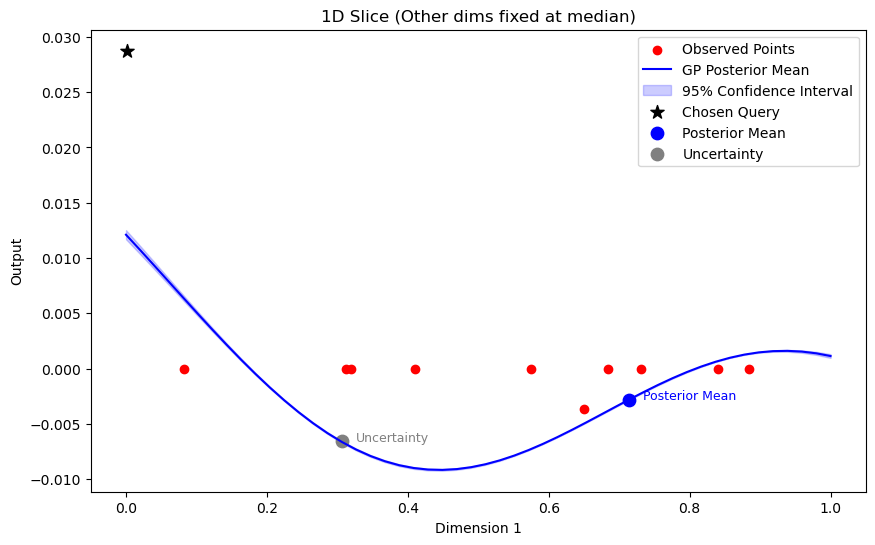

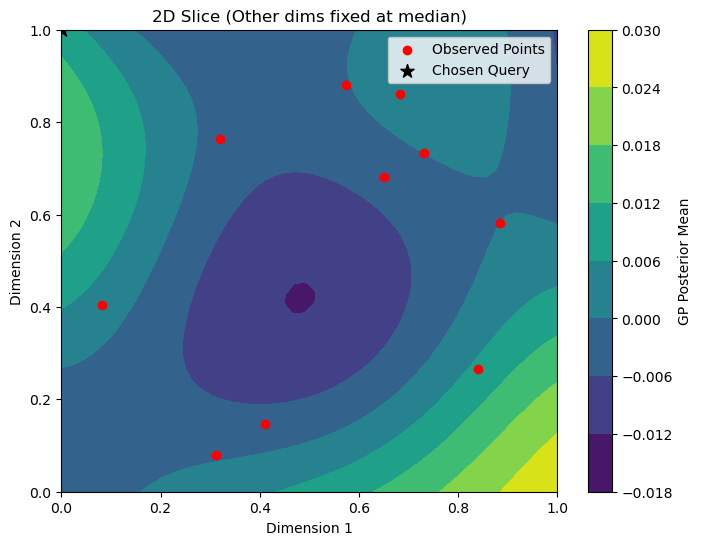

In [44]:

# Example usage
numeric_query, formatted_query = generate_hybrid_query(function_id=1)
print("Numeric query:", numeric_query)
print("Formatted query:", formatted_query)

# Visualize chosen query on GP slice plots
plot_gp_slice(X, Y, gp, dims_to_vary=[0], query_point=numeric_query)
plot_gp_slice(X, Y, gp, dims_to_vary=[0, 1], query_point=numeric_query)

